<div style="text-align: center; margin-bottom: 10px;">
  <img src="assets/logo.png" width="200">
</div>

<h1 style="text-align: center;">
Python Extension of DESeq2 Results
</h1>

<h3 style="text-align: center;">
Filtering, Annotation Mining, and Visualization of Differentially Expressed Genes
</h3>

<hr style="border: 1px solid #cfd8dc; width: 60%;">


## Executive summary

This notebook builds on a DESeq2 RNA-seq analysis of GSE203539, creating concise summaries, clear visualizations, and high-confidence DEG reports from annotated results.

### Workflow:
- apply a consistent DEG threshold: `adjusted p-value <= 0.005` and `|log2FC| > 2`
- compare AEC and AM responses across infection and inhibitor contrasts
- summarize DEG direction, top genes, and annotation-derived biological themes
- compare lightweight annotation themes against formal GO enrichment results from WebGestalt and GOrilla

### Key finding:
Influenza infection induced robust antiviral and inflammatory gene-expression responses, while inhibitor treatment reversed many of these infection-associated changes. Annotation-based theme extraction recovered many of the same broad biological patterns identified through formal GO enrichment, particularly for antiviral immune-response pathways.

## Imports

In [1]:
# Core libraries
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from nltk.stem import PorterStemmer

plt.style.use("seaborn-v0_8-whitegrid")
stemmer = PorterStemmer()

# Notebook display settings
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Input/output folders
DATA_DIR = Path("data")
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Filtering threshold used for high-confidence DEGs
PADJ_THRESHOLD = 0.005
LOG2FC_THRESHOLD = 2

# Shared visual styling
FIG_DPI = 300

# Brand palette 
COLOR_PRIMARY = "#17465A"      # deep navy
COLOR_SECONDARY = "#2FB7B5"    # teal
COLOR_ACCENT = "#8FA3AD"       # soft blue-gray
COLOR_NEUTRAL = "#566573"
GRID_COLOR = "#D7DEE2"

# Directional colors using brand-aligned contrast
COLOR_UP = COLOR_SECONDARY
COLOR_DOWN = COLOR_PRIMARY

def save_figure(fig, filename):
    """Save a figure to the notebook output folder with consistent settings."""
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")

## Load annotated DESeq2 result tables

This notebook uses annotated DESeq2 result tables generated from the upstream RNA-seq workflow. Each contrast table includes differential expression statistics and gene annotation metadata used for downstream reporting and visualization.

- `AEC_WSN_vs_mock_DESeq2_annot.txt`
- `AEC_WSNPP1_vs_WSN_DESeq2_annot.txt`
- `AM_WSN_vs_mock_DESeq2_annot.txt`
- `AM_WSNPP1_vs_WSN_DESeq2_annot.txt`
 
**Annotation source:** Ensembl Mus musculus GRCm39 gene annotation (`GRCm39_annotation.txt`)

In [2]:
# File registry for the four planned contrasts
contrast_files = [{"cell_type": "AEC",
                   "contrast": "WSN vs mock",
                   "file": DATA_DIR / "AEC_WSN_vs_mock_DESeq2_annot.txt"},
                  
                  {"cell_type": "AEC",
                   "contrast": "WSN_PP1 vs WSN",
                   "file": DATA_DIR / "AEC_WSNPP1_vs_WSN_DESeq2_annot.txt"},
                  
                  {"cell_type": "AM",
                   "contrast": "WSN vs mock",
                   "file": DATA_DIR / "AM_WSN_vs_mock_DESeq2_annot.txt"},
                  
                  {"cell_type": "AM",
                   "contrast": "WSN_PP1 vs WSN",
                   "file": DATA_DIR / "AM_WSNPP1_vs_WSN_DESeq2_annot.txt"}]

def load_contrast_table(record):
    """Load one annotated DESeq2 result table and add metadata columns."""
    path = record["file"]

    # Fail early if an expected input file is missing
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}\n"
                                "Check that the DESeq2 annotated result tables are saved in the data/ folder."
                               )

    # Read DESeq2 output and preserve its experimental context
    df = pd.read_csv(path, sep="\t")
    df["cell_type"] = record["cell_type"]
    df["contrast"] = record["contrast"]
    df["source_file"] = path.name
    return df

# Load all contrast tables and combine them into one analysis dataset
tables = [load_contrast_table(record) for record in contrast_files]
deg_raw = pd.concat(tables, ignore_index=True)

**Note:** Some adjusted p-values were smaller than Python's floating-point precision range and appeared as `0.0` after numeric conversion. The original adjusted p-value text was retained as `padj_raw` for reporting, while numeric `padj` was used for threshold filtering.

## Standardize and clean DEG result tables

DESeq2 and annotation outputs can use different column names depending on the export source. This section identifies common DEG and annotation fields, standardizes them into a consistent analysis table, and removes rows that cannot be evaluated for differential expression.

The standardized table includes:

- gene IDs and gene symbols
- log2 fold changes
- adjusted p-values
- annotation descriptions and biotypes
- experimental metadata including cell type and contrast

Rows with missing adjusted p-values or log2 fold changes are removed prior to downstream DEG filtering and visualization.

In [3]:
def find_first_existing_column(df, candidates):
    """Return the first column name present in df from a list of candidates."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


# Identify key columns, allowing for common DESeq2 / BioMart naming differences
gene_id_col = find_first_existing_column(deg_raw, ["GeneID",
                                                   "Gene.stable.ID",
                                                   "Gene.stable.ID.version"])

symbol_col = find_first_existing_column(deg_raw, ["Gene.name"])

description_col = find_first_existing_column(deg_raw, ["Gene.description"])

biotype_col = find_first_existing_column(deg_raw, ["Gene.type"])

gene_start_col = find_first_existing_column(deg_raw, ["Gene.start..bp."])

gene_end_col = find_first_existing_column(deg_raw, ["Gene.end..bp."])

transcript_id_col = find_first_existing_column(deg_raw, ["Transcript.stable.ID",
                                                         "Transcript.stable.ID.version"])

# Define columns required for DEG filtering and ranking
required = {"gene_id_col": gene_id_col,
            "log2FoldChange": "log2FoldChange" if "log2FoldChange" in deg_raw.columns else None,
            "padj": "padj" if "padj" in deg_raw.columns else None}

# Stop the notebook early if required columns are missing
missing_required = [name for name, value in required.items() if value is None]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Build standardized analysis table
deg = pd.DataFrame({"gene_id": deg_raw[gene_id_col].astype(str),
                    "gene_symbol": deg_raw[symbol_col].astype(str) if symbol_col else deg_raw[gene_id_col].astype(str),
                    "log2FoldChange": pd.to_numeric(deg_raw["log2FoldChange"], errors="coerce"),
                    "padj_raw": deg_raw["padj"].astype(str),
                    "padj": pd.to_numeric(deg_raw["padj"], errors="coerce"),
                    "cell_type": deg_raw["cell_type"],
                    "contrast": deg_raw["contrast"],
                    "source_file": deg_raw["source_file"]})

# Add optional annotation fields when available
deg["description"] = deg_raw[description_col].astype(str) if description_col else ""
deg["biotype"] = deg_raw[biotype_col].astype(str) if biotype_col else "unknown"

# Convert placeholder text values into true missing values
for col in ["gene_symbol", "description", "biotype"]:
    deg[col] = (deg[col].replace({"nan": np.nan, "None": np.nan, "": np.nan}))

# Use gene ID as a fallback label when a gene symbol is unavailable
deg["gene_label"] = deg["gene_symbol"].fillna(deg["gene_id"])

# Remove rows that cannot be evaluated for statistical significance
before = len(deg)
deg = deg.dropna(subset=["padj", "log2FoldChange"]).copy()
after = len(deg)

print(f"Rows retained after DEG table cleanup: {after:,}")

Rows retained after DEG table cleanup: 78,853


## Add genomic metadata from BioMart

Additional gene-level metadata was downloaded from Ensembl BioMart and joined to the DESeq2 results using Ensembl gene stable IDs. This adds chromosome, strand, transcript count, and GC content for downstream summaries and visualization.

In [4]:
biomart_path = DATA_DIR / "biomart_mouse_gene_metadata.txt"

if not biomart_path.exists():
    raise FileNotFoundError(f"Missing file: {biomart_path}\n"
                            "Check that BioMart metadata is saved in the data/ folder.")

biomart = pd.read_csv(biomart_path, sep="\t")

biomart_column_map = {"Gene stable ID": "gene_id",
                      "Chromosome/scaffold name": "chromosome",
                      "Strand": "strand",
                      "Transcript count": "transcript_count",
                      "Gene % GC content": "gene_gc_content"}

if "Gene stable ID" not in biomart.columns:
    raise ValueError("BioMart metadata must include 'Gene stable ID' for joining to DESeq2 results.")

available_biomart_map = {source: target for source, target in biomart_column_map.items()
                         if source in biomart.columns}
missing_optional_biomart = sorted(set(biomart_column_map) - set(available_biomart_map) - {"Gene stable ID"})

biomart = biomart.rename(columns=available_biomart_map)

# Add optional metadata columns as missing values when absent so later code remains stable
for optional_col in ["chromosome", "strand", "transcript_count", "gene_gc_content"]:
    if optional_col not in biomart.columns:
        biomart[optional_col] = np.nan

# Keep one row per gene ID
biomart = biomart.drop_duplicates(subset="gene_id")

# Join BioMart metadata onto DESeq2 results
deg = deg.merge(biomart[["gene_id", "chromosome", "strand", "transcript_count", "gene_gc_content"]],
                on="gene_id",
                how="left")

## High-confidence DEG filtering

High-confidence DEGs are defined using:

- `p-adjusted <= 0.005`
- `|log2FoldChange| > 2`

These thresholds were chosen to focus downstream interpretation on the most biologically meaningful transcriptional changes across contrasts.

In [5]:
def classify_deg(row):
    """Classify genes using adjusted p-value and log2 fold-change thresholds."""
    if row["padj"] <= PADJ_THRESHOLD and row["log2FoldChange"] > LOG2FC_THRESHOLD:
        return "Upregulated"
    if row["padj"] <= PADJ_THRESHOLD and row["log2FoldChange"] < -LOG2FC_THRESHOLD:
        return "Downregulated"
    return "Not high-confidence"


# Apply DEG classification to each row
deg["regulation"] = deg.apply(classify_deg, axis=1)

# Create a Boolean flag for easier filtering downstream
deg["is_high_confidence_deg"] = deg["regulation"].isin(["Upregulated", "Downregulated"])

# Map technical contrast names to plain-language biological questions
contrast_label_map = {("AEC", "WSN vs mock"): "Infection response",
                      ("AEC", "WSN_PP1 vs WSN"): "Inhibitor effect",
                      ("AM", "WSN vs mock"): "Infection response",
                      ("AM", "WSN_PP1 vs WSN"): "Inhibitor effect"}

# Add biological context while preserving the original contrast label
deg["biological_question"] = deg.apply(lambda row: contrast_label_map.get((row["cell_type"], row["contrast"]), row["contrast"]), axis=1)

# Keep only high-confidence DEGs for downstream summaries and plots
high_conf = deg[deg["is_high_confidence_deg"]].copy()

if high_conf.empty:
    raise ValueError("No high-confidence DEGs were found. Check thresholds, input files, and required DEG columns.")

print(f"High-confidence DEGs: {len(high_conf):,}")

High-confidence DEGs: 3,575


## Quality-control overview: GC content distribution

GC content distributions are reviewed as a sequence-composition quality check across contrasts. No major global shifts or obvious technical artifacts were observed among the high-confidence DEG subsets.

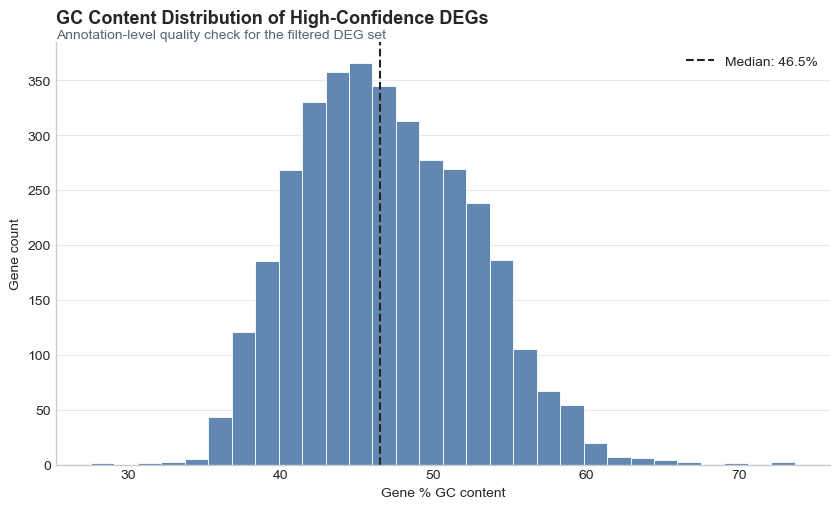

In [6]:
gc_values = pd.to_numeric(high_conf["gene_gc_content"], errors="coerce").dropna()

if gc_values.empty:
    print("No GC-content values available for high-confidence DEGs; skipping GC distribution plot.")
else:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    ax.hist(gc_values, bins=30, color="#4C78A8", edgecolor="white", linewidth=0.7, alpha=0.88)
    ax.axvline(gc_values.median(), color="#222222", linewidth=1.5, linestyle="--",
               label=f"Median: {gc_values.median():.1f}%")

    ax.set_title("GC Content Distribution of High-Confidence DEGs", loc="left", pad=14, fontsize=13, weight="bold")
    ax.text(0, 1.01,
            "Annotation-level quality check for the filtered DEG set",
            transform=ax.transAxes, fontsize=10, color=COLOR_NEUTRAL)
    ax.set_xlabel("Gene % GC content")
    ax.set_ylabel("Gene count")

    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color=GRID_COLOR, alpha=0.65)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    save_figure(fig, "figure_3_gc_content_distribution.png")
    plt.show()

## DEG count summaries

This section aggregates high-confidence DEG counts across contrasts.

These tables are useful for quickly comparing the magnitude and direction of transcriptional response between:

- AEC vs AM cell types
- infection response contrasts
- inhibitor effect contrasts


In [7]:
# Count genes by cell type, biological question, contrast, and DEG classification
summary_counts = (deg.groupby(["cell_type", "biological_question", "contrast", "regulation"]).size().reset_index(name="gene_count"))

# Reshape counts so each regulation category becomes its own column
summary_pivot = (summary_counts.pivot_table(index=["cell_type", "biological_question", "contrast"],
                                            columns="regulation",
                                            values="gene_count",
                                            fill_value=0).reset_index())

# Ensure expected columns exist even if no genes fall into a category
for col in ["Upregulated", "Downregulated", "Not high-confidence"]:
    if col not in summary_pivot.columns:
        summary_pivot[col] = 0

# Total high-confidence DEGs are the upregulated and downregulated genes
summary_pivot["High-confidence total"] = (summary_pivot["Upregulated"] + summary_pivot["Downregulated"])

# Reorder columns for readability
summary_pivot = summary_pivot[["cell_type",
                               "biological_question",
                               "contrast",
                               "Upregulated",
                               "Downregulated",
                               "High-confidence total",
                               "Not high-confidence"]]

# Save summary table for reporting
summary_pivot.to_csv(OUTPUT_DIR / "deg_summary_counts.csv", index=False)

## Top ranked genes

For each contrast, genes are ranked by:

1. adjusted p-value
2. absolute log2 fold change

This produces compact top-gene tables for downstream interpretation.


In [8]:
def get_top_genes(df, direction, n=10):
    """Return top genes in one regulation direction for each contrast."""
    out = []

    # Rank genes separately within each cell type and contrast
    for (cell_type, contrast), sub in df[df["regulation"] == direction].groupby(["cell_type", "contrast"]):
        ranked = (sub.assign(abs_log2fc=sub["log2FoldChange"].abs()).sort_values(["padj", "abs_log2fc"], ascending=[True, False]).head(n).copy())

        # Preserve whether the ranking came from the upregulated or downregulated set
        ranked["rank_direction"] = direction
        out.append(ranked)

    # Return an empty table if no genes match the requested direction
    if not out:
        return pd.DataFrame()

    return pd.concat(out, ignore_index=True)


# Get top upregulated and downregulated genes for each contrast
top_up = get_top_genes(deg, "Upregulated", n=10)
top_down = get_top_genes(deg, "Downregulated", n=10)
top_genes = pd.concat([top_up, top_down], ignore_index=True)

# Display compact fields for interpretation
display_cols = ["cell_type", "contrast", "rank_direction", "gene_label",
                "log2FoldChange", "padj", "biotype", "chromosome"]

# Save top gene table
top_genes[display_cols + ["gene_id", "description"]].to_csv(OUTPUT_DIR / "top_high_confidence_genes.csv", index=False)

## Visualization 1: DEG direction and magnitude

This figure compares strongly up- and downregulated genes across infection and inhibitor contrasts. Infection produced broad immune activation, while inhibitor treatment shifted many infection-associated genes in the opposite direction.

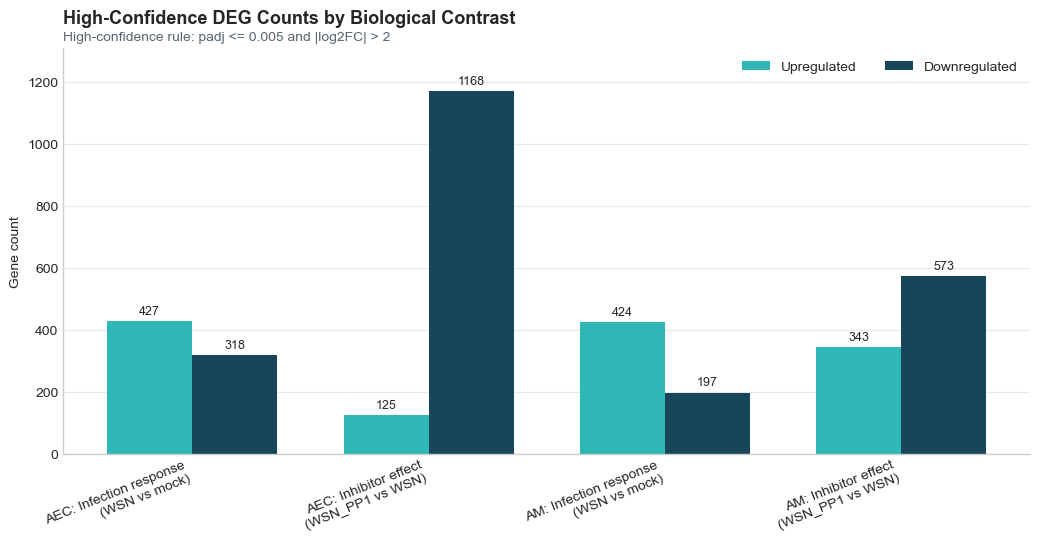

In [9]:
plot_df = summary_pivot.copy()

# Add concise biological context to x-axis labels
plot_df["comparison"] = (plot_df["cell_type"] + ": " + plot_df["biological_question"] + "\n" + "(" + plot_df["contrast"] + ")")

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10.5, 5.6))

up_bars = ax.bar(x - width/2, plot_df["Upregulated"], width,
                 label="Upregulated", color=COLOR_UP)
down_bars = ax.bar(x + width/2, plot_df["Downregulated"], width,
                   label="Downregulated", color=COLOR_DOWN)

ax.bar_label(up_bars, padding=3, fontsize=9)
ax.bar_label(down_bars, padding=3, fontsize=9)

ax.set_title("High-Confidence DEG Counts by Biological Contrast", loc="left", pad=18, fontsize=13, weight="bold")
ax.text(0, 1.02,
        f"High-confidence rule: padj <= {PADJ_THRESHOLD} and |log2FC| > {LOG2FC_THRESHOLD}",
        transform=ax.transAxes, fontsize=10, color=COLOR_NEUTRAL)

ax.set_ylabel("Gene count")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["comparison"], rotation=22, ha="right")

ax.legend(frameon=False, ncol=2, loc="upper right")
ax.grid(axis="y", color=GRID_COLOR, alpha=0.65)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(y=0.12)

plt.tight_layout()
save_figure(fig, "figure_1_high_confidence_deg_counts.png")
plt.show()

## Visualization 2: Largest transcriptional shifts

The strongest fold-change responses were dominated by interferon-stimulated genes, cytokines, and inflammatory mediators associated with influenza infection and host immune signaling.


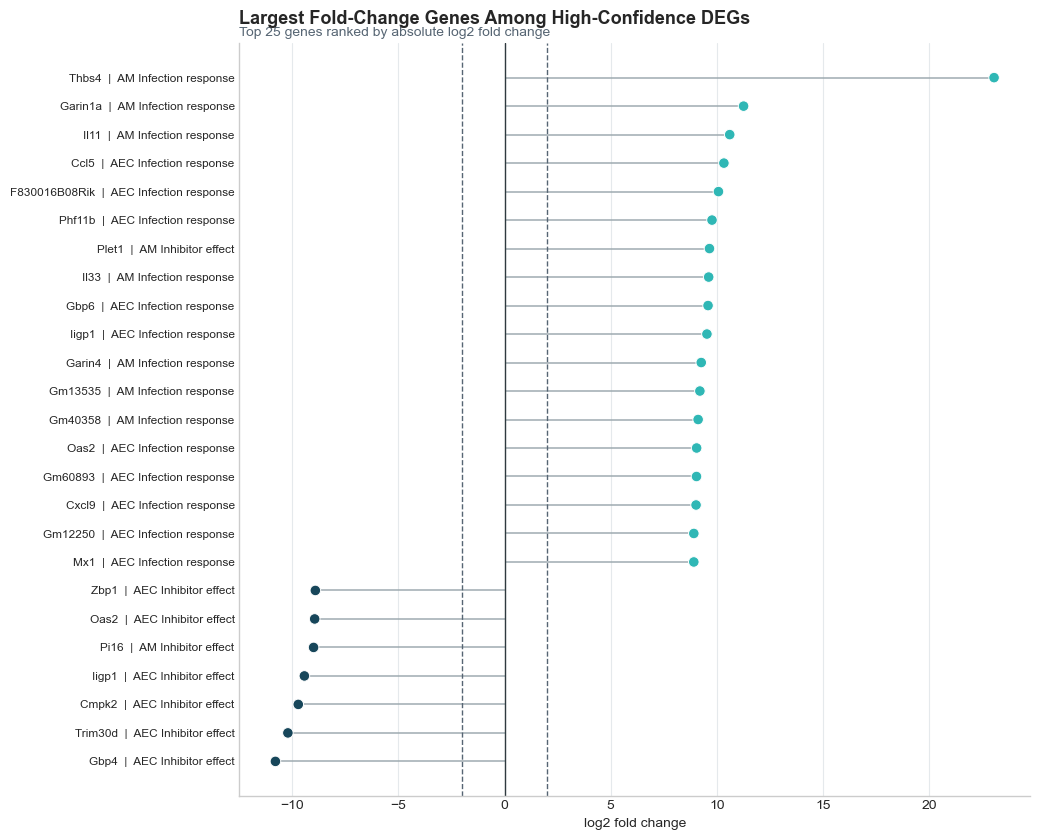

In [10]:
# Select strongest genes by absolute log2 fold change
top_lollipop = (
    high_conf
    .assign(abs_log2fc=high_conf["log2FoldChange"].abs())
    .sort_values("abs_log2fc", ascending=False)
    .head(25)
    .copy()
)

top_lollipop["label"] = (
    top_lollipop["gene_label"].astype(str) + "  |  " +
    top_lollipop["cell_type"] + " " +
    top_lollipop["biological_question"]
)

top_lollipop = top_lollipop.sort_values("log2FoldChange")

fig, ax = plt.subplots(figsize=(10.5, 8.5))

y = np.arange(len(top_lollipop))
point_colors = top_lollipop["regulation"].map({
    "Upregulated": COLOR_UP,
    "Downregulated": COLOR_DOWN
})

ax.hlines(
    y=y,
    xmin=0,
    xmax=top_lollipop["log2FoldChange"],
    color="#9AA7AD",
    linewidth=1.4,
    alpha=0.75
)

ax.scatter(
    top_lollipop["log2FoldChange"],
    y,
    s=58,
    color=point_colors,
    edgecolor="white",
    linewidth=0.7,
    zorder=3
)

ax.axvline(0, color="#2F3A3F", linewidth=1)
ax.axvline(LOG2FC_THRESHOLD, color=COLOR_NEUTRAL, linestyle="--", linewidth=1)
ax.axvline(-LOG2FC_THRESHOLD, color=COLOR_NEUTRAL, linestyle="--", linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels(top_lollipop["label"], fontsize=8.5)

ax.set_xlabel("log2 fold change")
ax.set_ylabel("")

ax.set_title(
    "Largest Fold-Change Genes Among High-Confidence DEGs",
    loc="left",
    pad=14,
    fontsize=13,
    weight="bold"
)

ax.text(
    0,
    1.01,
    "Top 25 genes ranked by absolute log2 fold change",
    transform=ax.transAxes,
    fontsize=10,
    color=COLOR_NEUTRAL
)

ax.grid(axis="x", color=GRID_COLOR, alpha=0.65)
ax.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_figure(fig, "figure_2_top_fold_change_lollipop.png")
plt.show()

## Annotation theme extraction

In [11]:
# GO theme summary and keyword map

formal_go_summary = pd.DataFrame([
    {"cell_type": "AEC", "contrast": "WSN vs mock", "direction": "Upregulated",
     "tool": "WebGestalt", "top_go_term": "defense response to other organism",
     "go_id": "GO:0098542", "fdr_or_rank": "top term",
     "biological_theme": "antiviral innate immune response"},
    {"cell_type": "AEC", "contrast": "WSN vs mock", "direction": "Upregulated",
     "tool": "GOrilla", "top_go_term": "response to other organism",
     "go_id": "GO:0051707", "fdr_or_rank": "top term",
     "biological_theme": "antiviral innate immune response"},
    {"cell_type": "AEC", "contrast": "WSN_PP1 vs WSN", "direction": "Downregulated",
     "tool": "WebGestalt", "top_go_term": "cellular response to interferon-beta",
     "go_id": "GO:0035458", "fdr_or_rank": "FDR 1.63E-28",
     "biological_theme": "interferon beta response"},
    {"cell_type": "AEC", "contrast": "WSN_PP1 vs WSN", "direction": "Downregulated",
     "tool": "GOrilla", "top_go_term": "cellular response to interferon-beta",
     "go_id": "GO:0035458", "fdr_or_rank": "FDR 1.63E-28",
     "biological_theme": "interferon beta response"},
    {"cell_type": "AM", "contrast": "WSN vs mock", "direction": "Upregulated",
     "tool": "WebGestalt", "top_go_term": "cytokine-mediated signaling pathway",
     "go_id": "GO:0019221", "fdr_or_rank": "top term",
     "biological_theme": "cytokine signaling and inflammatory response"},
    {"cell_type": "AM", "contrast": "WSN vs mock", "direction": "Upregulated",
     "tool": "GOrilla", "top_go_term": "regulation of response to stimulus",
     "go_id": "GO:0048583", "fdr_or_rank": "top term",
     "biological_theme": "stimulus response regulation"},
    {"cell_type": "AM", "contrast": "WSN_PP1 vs WSN", "direction": "Mixed high-confidence",
     "tool": "WebGestalt", "top_go_term": "defense response",
     "go_id": "GO:0006952", "fdr_or_rank": "top term",
     "biological_theme": "immune defense and leukocyte recruitment"},
    {"cell_type": "AM", "contrast": "WSN_PP1 vs WSN", "direction": "Mixed high-confidence",
     "tool": "GOrilla", "top_go_term": "receptor ligand activity",
     "go_id": "GO:0048018", "fdr_or_rank": "top term",
     "biological_theme": "receptor ligand signaling"},
    {"cell_type": "AM", "contrast": "WSN_PP1 vs WSN", "direction": "Downregulated",
     "tool": "GOrilla", "top_go_term": "positive regulation of RNA metabolic process",
     "go_id": "GO:0051254", "fdr_or_rank": "FDR 2.47E-11",
     "biological_theme": "RNA metabolic regulation"},
    {"cell_type": "AM", "contrast": "WSN_PP1 vs WSN", "direction": "Downregulated",
     "tool": "WebGestalt", "top_go_term": "interleukin-5 production",
     "go_id": "GO:0032634", "fdr_or_rank": "enrichment ratio 10.5; FDR 0.013",
     "biological_theme": "interleukin and cytokine production"}
])

theme_keyword_map = {
    "antiviral innate immune response": ["antiviral", "virus", "viral", "interferon", "defense", "immune", "response"],
    "interferon beta response": ["interferon", "beta", "cytokine", "immune", "response", "inflammatory"],
    "cytokine signaling and inflammatory response": ["cytokine", "chemokine", "interleukin", "inflammatory", "immune", "signaling", "response"],
    "stimulus response regulation": ["response", "stimulus", "regulation", "immune", "cytokine", "signaling"],
    "immune defense and leukocyte recruitment": ["defense", "immune", "leukocyte", "chemokine", "cytokine", "migration", "response"],
    "receptor ligand signaling": ["receptor", "ligand", "signaling", "cytokine", "chemokine"],
    "RNA metabolic regulation": ["rna", "metabolic", "transcription", "regulation", "process"],
    "interleukin and cytokine production": ["interleukin", "cytokine", "production", "inflammatory", "immune"]
}

# Stopwords for annotation theme extraction
# "transcription" is retained because it is used for RNA metabolic GO concordance.
stopwords = {
    "the", "and", "or", "of", "to", "in", "a", "an",
    "for", "with", "by", "on", "at", "from", "as",
    "is", "are", "was", "were", "be", "this", "that",
    "mouse", "mus", "musculus",
    "gene", "genes", "protein", "proteins",
    "factor", "activity", "related", "associated",
    "member", "group", "type", "complex",
    "chain", "subunit", "subfamily",
    "family", "superfamily", "homolog",
    "predicted", "uncharacterized",
    "putative", "hypothetical",
    "source", "coding",
    "acc", "mgi", "cdna",
    "riken", "ensembl",
    "domain", "domains",
    "motif", "repeat", "rich",
    "containing", "coiled", "coil",
    "tripartite", "trim",
    "zinc", "finger",
    "transmembrane",
    "sequence", "strand",
    "open", "reading", "frame",
    "nucleotide", "acid",
    "region", "clade",
    "binding", "kinase",
    "receptor", "coupled",
    "alpha", "beta", "gamma", "delta",
    "variant", "isoform",
    "symbol", "polypeptide",
    "opposite",
    "small", "large",
    "cold"
}

# Lightweight synonym normalization before stemming
stem_keywords = {
    "cytokines": "cytokine",
    "chemokine": "cytokine",
    "chemokines": "cytokine",
    "interleukins": "interleukin",
    "viral": "virus",
    "viruses": "virus",
    "influenza": "virus",
    "antivirals": "antiviral",
    "immunity": "immune",
    "immunological": "immune",
    "inflammatory": "inflammation",
    "inflamed": "inflammation",
    "signals": "signaling",
    "signal": "signaling",
    "signalling": "signaling",
    "receptors": "receptor",
    "ligands": "ligand",
    "regulatory": "regulation",
    "regulated": "regulation",
    "regulates": "regulation",
    "metabolic": "metabolism",
    "recruitment": "migration",
    "migratory": "migration"
}


def normalize_token(token):
    """Apply lightweight synonym normalization to annotation tokens."""
    return stem_keywords.get(token, token)


def tokenize_annotation(text):
    """Tokenize annotation text into lowercase, filtered, stemmed word tokens."""
    if pd.isna(text):
        return []

    tokens = re.findall(r"[a-z]{4,}", str(text).lower())

    return [
        stemmer.stem(normalize_token(token))
        for token in tokens
        if token not in stopwords
    ]


def make_bigrams(tokens):
    """Create adjacent two-word phrases from token list."""
    return [
        f"{tokens[i]} {tokens[i + 1]}"
        for i in range(len(tokens) - 1)
    ]


def stem_terms(words):
    """Stem and normalize keyword terms for concordance matching."""
    return {
        stemmer.stem(normalize_token(word.lower()))
        for word in words
    }


def phrase_matches_theme(phrase, keywords):
    """Return True when a phrase contains at least one normalized/stemmed theme keyword."""
    phrase_tokens = {
        stemmer.stem(normalize_token(token))
        for token in re.findall(r"[a-z]+", str(phrase).lower())
    }

    keyword_tokens = stem_terms(keywords)

    return bool(phrase_tokens.intersection(keyword_tokens))


# Use annotation fields only; exclude biotype because it adds metadata noise
high_conf["annotation_text"] = (
    high_conf["gene_label"].fillna("").astype(str) + " " +
    high_conf["description"].fillna("").astype(str)
)


def top_phrases_for_group(df, cell_type, contrast, regulation=None, n=10):
    """Return the most common normalized annotation phrases for one group."""
    sub = df[
        (df["cell_type"] == cell_type) &
        (df["contrast"] == contrast)
    ]

    if regulation in {"Upregulated", "Downregulated"}:
        sub = sub[sub["regulation"] == regulation]

    phrases = []

    for text in sub["annotation_text"]:
        tokens = tokenize_annotation(text)
        phrases.extend(make_bigrams(tokens))

    return pd.DataFrame(
        Counter(phrases).most_common(n),
        columns=["phrase", "count"]
    )


# GO/text-theme concordance
concordance_rows = []

for _, row in formal_go_summary.iterrows():
    regulation = (
        row["direction"]
        if row["direction"] in {"Upregulated", "Downregulated"}
        else None
    )

    phrases = top_phrases_for_group(
        high_conf,
        row["cell_type"],
        row["contrast"],
        regulation=regulation,
        n=10
    )

    phrase_list = phrases["phrase"].tolist()
    keywords = theme_keyword_map[row["biological_theme"]]

    matching_phrases = [
        phrase for phrase in phrase_list
        if phrase_matches_theme(phrase, keywords)
    ]

    phrase_count = len(phrase_list)

    concordance_rows.append({
        "cell_type": row["cell_type"],
        "contrast": row["contrast"],
        "direction": row["direction"],
        "tool": row["tool"],
        "top_go_term": row["top_go_term"],
        "go_id": row["go_id"],
        "fdr_or_rank": row["fdr_or_rank"],
        "biological_theme": row["biological_theme"],
        "theme_keywords": ", ".join(keywords),
        "top_text_mined_phrases": "; ".join(phrase_list),
        "matching_text_mined_phrases": "; ".join(matching_phrases),
        "theme_match_count": len(matching_phrases),
        "top_phrase_count": phrase_count,
        "theme_match_proportion": (
            len(matching_phrases) / phrase_count
            if phrase_count else np.nan
        )
    })

theme_concordance = pd.DataFrame(concordance_rows)

formal_go_summary.to_csv(
    OUTPUT_DIR / "formal_go_summary_table.csv",
    index=False
)

theme_concordance.to_csv(
    OUTPUT_DIR / "text_mining_go_theme_concordance.csv",
    index=False
)

## Visualization 3: Normalized Annotation Themes

RNA-seq interpretation often requires moving across multiple specialized tools, annotation databases, and enrichment websites that each capture different aspects of the biological signal.

This section uses lightweight annotation-based theme extraction to summarize recurring biological terms directly from gene annotations, then compares those patterns against formal GO enrichment results from WebGestalt and GOrilla.

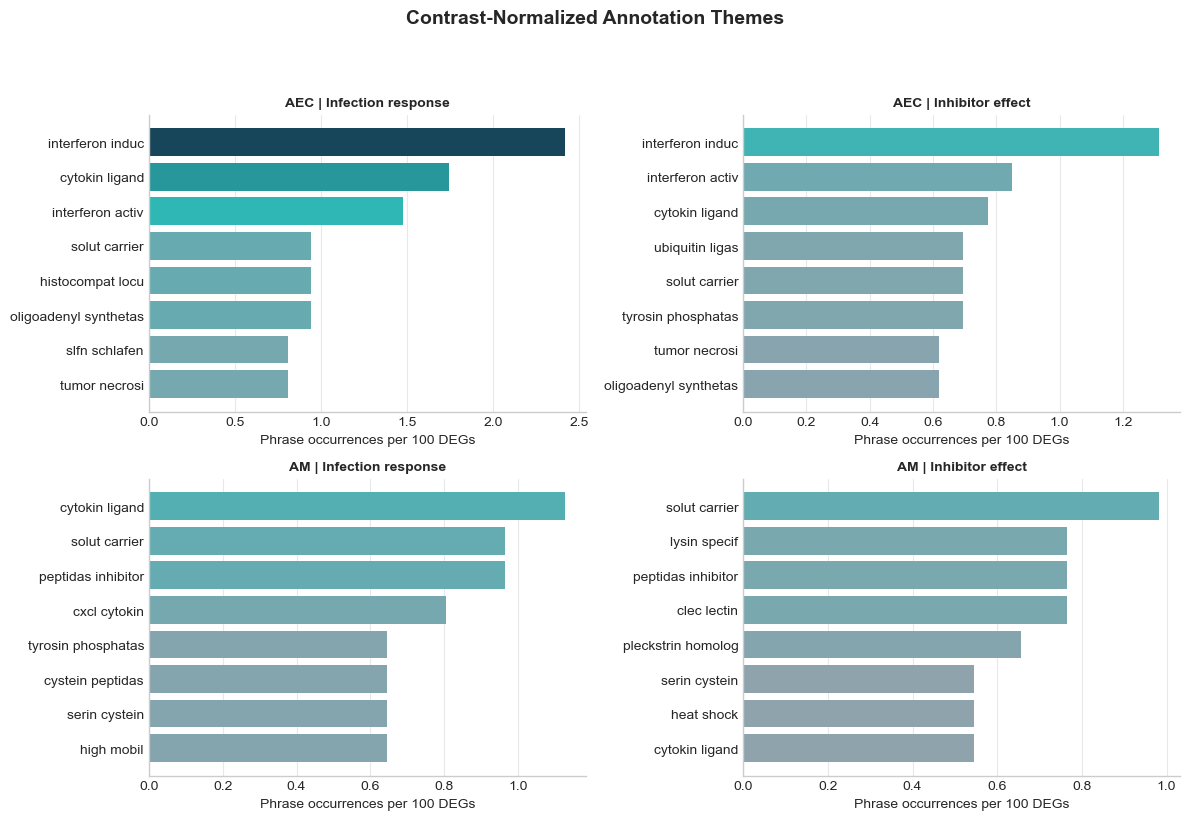

In [12]:
# Add readable labels before grouping
high_conf["cell_contrast"] = (
    high_conf["cell_type"].astype(str) + " | " +
    high_conf["biological_question"].astype(str)
)

# Build contrast-normalized phrase table
phrase_rows = []

for group, df in high_conf.groupby("cell_contrast"):
    total_genes = df["gene_id"].nunique()

    phrase_counts = Counter(
        phrase
        for text in df["annotation_text"]
        for phrase in make_bigrams(tokenize_annotation(text))
    )

    for phrase, count in phrase_counts.items():
        phrase_rows.append({
            "cell_contrast": group,
            "phrase": phrase,
            "count": count,
            "n_genes": total_genes,
            "phrase_occurrences_per_100_DEGs": count / total_genes * 100
        })

phrase_by_contrast = pd.DataFrame(phrase_rows)

plot_df = (
    phrase_by_contrast
    .sort_values(
        ["cell_contrast", "phrase_occurrences_per_100_DEGs"],
        ascending=[True, False]
    )
    .groupby("cell_contrast")
    .head(8)
    .reset_index(drop=True)
)

norm = mcolors.Normalize(
    vmin=plot_df["phrase_occurrences_per_100_DEGs"].min(),
    vmax=plot_df["phrase_occurrences_per_100_DEGs"].max()
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "brand_amplitude",
    [COLOR_ACCENT, COLOR_SECONDARY, COLOR_PRIMARY]
)

groups = plot_df["cell_contrast"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for ax, group in zip(axes.flat, groups):
    df_group = (
        plot_df[plot_df["cell_contrast"] == group]
        .sort_values("phrase_occurrences_per_100_DEGs")
    )

    values = df_group["phrase_occurrences_per_100_DEGs"]

    ax.barh(
        df_group["phrase"],
        values,
        color=[cmap(norm(v)) for v in values]
    )

    ax.set_title(group, fontsize=10, weight="bold")
    ax.set_xlabel("Phrase occurrences per 100 DEGs")
    ax.set_ylabel("")
    ax.grid(axis="x", color=GRID_COLOR, alpha=0.65)
    ax.grid(axis="y", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Contrast-Normalized Annotation Themes",
    fontsize=14,
    weight="bold",
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, "figure_4_contrast_normalized_annotation_phrases.png")
plt.show()

Frequent annotation phrases were dominated by interferon-related and immune signaling terms, particularly in AEC contrasts, consistent with antiviral response programs during influenza infection. Chemokine, ubiquitin ligase, peptidase inhibitor, and cytokine-associated annotations also appeared across contrasts, supporting broader inflammatory and host-response patterns that aligned directionally with formal GO enrichment results.

## Visualization 4: Concordance with formal GO enrichment

Top annotation phrases are compared with selected WebGestalt and GOrilla themes from the formal GO analysis. This comparison is descriptive only and does not replace statistical enrichment testing.

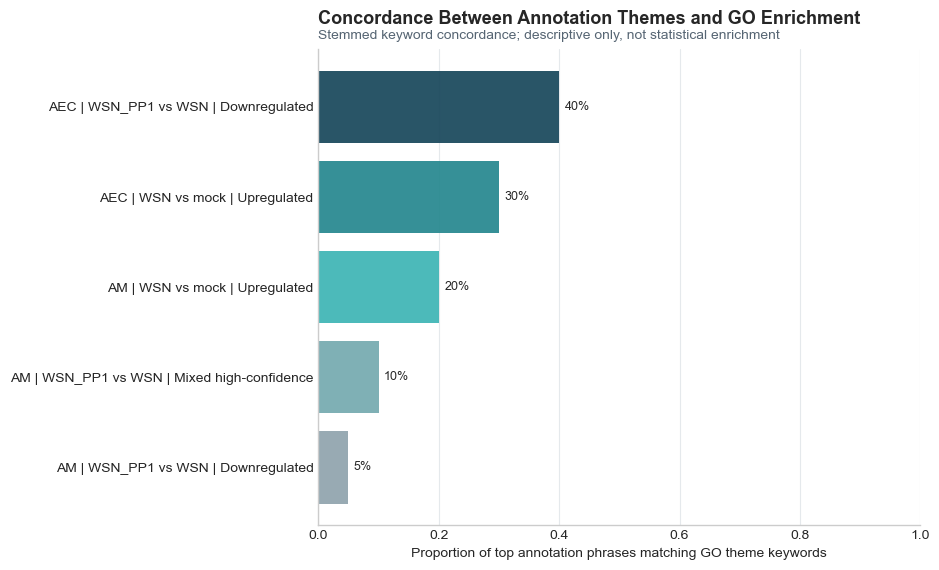

In [13]:
plot_concordance = (
    theme_concordance
    .assign(
        group=lambda d: (
            d["cell_type"] + " | " +
            d["contrast"] + " | " +
            d["direction"]
        )
    )
    .groupby(["group"], as_index=False)["theme_match_proportion"]
    .mean()
    .sort_values("theme_match_proportion")
)

fig, ax = plt.subplots(figsize=(9.5, 5.8))

norm = plt.Normalize(
    vmin=plot_concordance["theme_match_proportion"].min(),
    vmax=plot_concordance["theme_match_proportion"].max()
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "brand_amplitude",
    [COLOR_ACCENT, COLOR_SECONDARY, COLOR_PRIMARY]
)

bar_colors = cmap(norm(plot_concordance["theme_match_proportion"]))

bars = ax.barh(
    plot_concordance["group"],
    plot_concordance["theme_match_proportion"],
    color=bar_colors,
    alpha=0.92
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.0%}" if pd.notna(value) else "NA"
        for value in plot_concordance["theme_match_proportion"]
    ],
    padding=4,
    fontsize=9
)

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of top annotation phrases matching GO theme keywords")
ax.set_ylabel("")

ax.set_title(
    "Concordance Between Annotation Themes and GO Enrichment",
    loc="left",
    pad=18,
    fontsize=13,
    weight="bold"
)

ax.text(
    0,
    1.02,
    "Stemmed keyword concordance; descriptive only, not statistical enrichment",
    transform=ax.transAxes,
    fontsize=10,
    color=COLOR_NEUTRAL
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", color=GRID_COLOR, alpha=0.65)
ax.grid(axis="y", visible=False)

plt.tight_layout()
save_figure(fig, "figure_5_text_mining_go_theme_concordance.png")
plt.show()

Concordance was strongest in AEC infection-response contrasts, where interferon and antiviral programs produced repetitive annotation language that aligned closely with formal GO enrichment themes. Lower concordance in AM contrasts likely reflects broader, more heterogeneous inflammatory programs, which are captured more effectively through ontology-based enrichment than by direct annotation phrase frequency alone.

## Export clean DEG reporting table

A compact high-confidence DEG table is exported for reporting and follow-up analysis.

In [14]:
# Create a compact export table
report_table = high_conf[[
    "cell_type",
    "biological_question",
    "contrast",
    "gene_id",
    "gene_label",
    "regulation",
    "log2FoldChange",
    "padj",
    "biotype",
    "chromosome",
    "description"
]].copy()

# Clean annotation descriptions for readability
report_table["description"] = (
    report_table["description"]
    .fillna("")
    .astype(str)
    .str.replace(r"\[.*?\]", "", regex=True)
    .str.replace(r"RIKEN cDNA", "", regex=False)
    .str.replace(r"predicted gene,", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Add absolute effect size for easier ranking
report_table["abs_log2FoldChange"] = (
    report_table["log2FoldChange"].abs()
)

# Sort before formatting numeric columns
report_table = report_table.sort_values(
    ["cell_type",
     "biological_question",
     "contrast",
     "padj",
     "abs_log2FoldChange"],
    ascending=[True, True, True, True, False]
)

# Format numeric columns for readability
report_table["log2FoldChange"] = (
    report_table["log2FoldChange"].round(3)
)

report_table["abs_log2FoldChange"] = (
    report_table["abs_log2FoldChange"].round(3)
)

report_table["padj"] = (
    report_table["padj"]
    .apply(lambda x: f"{x:.2e}")
)

# Reorder columns for reporting
report_table = report_table[[
    "cell_type",
    "biological_question",
    "contrast",
    "gene_label",
    "gene_id",
    "regulation",
    "log2FoldChange",
    "abs_log2FoldChange",
    "padj",
    "biotype",
    "chromosome",
    "description"
]]

# Save clean report table
report_table.to_csv(OUTPUT_DIR / "high_confidence_deg_report_table.csv", index=False)

## Reporting outputs

Clean tables and figures were exported for review, reproducibility, and portfolio presentation.

## Interpretation and limitations

This notebook summarizes downstream DESeq2 results across AEC and AM contrasts using consistent DEG thresholds, compact visualizations, and annotation-based theme extraction.

Key takeaways:
- Influenza infection produced strong antiviral and inflammatory transcriptional signatures.
- Inhibitor treatment shifted many infection-associated genes in the opposite direction, consistent with partial transcriptional reversal.
- Annotation theme extraction showed strongest agreement with GO enrichment in interferon and antiviral-response programs.
- Lower concordance in AM contrasts likely reflects broader macrophage inflammatory biology better captured by formal ontology-based enrichment.

Limitations:
- Annotation theme extraction is descriptive and does not replace GO enrichment.
- Results depend on upstream DESeq2 outputs and annotation quality.
- This is bulk RNA-seq from a single timepoint, so functional conclusions remain correlative.